 kx    ky    kz      Q_xy^{-+} (numeric)       Q_xy^{-+} (analytical)
 0.20  0.30  0.40     0.689655172414         0.689655172414
 1.00  0.50  0.00    -0.000000000000         0.000000000000
 0.00  0.40  0.50     0.609756097561         0.609756097561


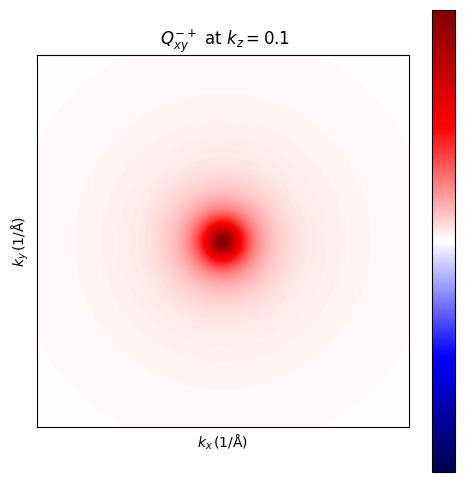

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# ---------------- Pauli matrices ----------------
sx = np.array([[0, 1], [1, 0]], dtype=complex)
sy = np.array([[0, -1j], [1j, 0]], dtype=complex)
sz = np.array([[1, 0], [0, -1]], dtype=complex)

# ---------------- Physical constants ----------------
ħ_eVs = 6.582119569e-16   # Planck's constant hbar in eV·s
vF_A_per_s = 1e16         # Fermi velocity in Å/s

# ---------------- Hamiltonian ----------------
def H_weyl(kx, ky, kz, vF=vF_A_per_s, ħ=ħ_eVs):
    return ħ * vF * (kx * sx + ky * sy + kz * sz)

# ---------------- Derivatives ----------------
def dH_dkx(vF=vF_A_per_s, ħ=ħ_eVs):
    return ħ * vF * sx

# ---------------- Diagonalization ----------------
def diagonalize_and_assign(H):
    evals, evecs = np.linalg.eigh(H)
    if evals[0] < evals[1]:
        return evals[0], evals[1], evecs[:, 0], evecs[:, 1]  # (E-, E+, u-, u+)
    else:
        return evals[1], evals[0], evecs[:, 1], evecs[:, 0]

# ---------------- Numeric Q_xy^{-+} ----------------
def compute_Q_xy_minus_plus(kx, ky, kz, vF=vF_A_per_s, ħ=ħ_eVs, eps=1e-12):
    H = H_weyl(kx, ky, kz, vF, ħ)
    dHkx = dH_dkx(vF, ħ)
    sigma_y = sy

    E_minus, E_plus, u_minus, u_plus = diagonalize_and_assign(H)
    denom = (E_plus - E_minus)
    if abs(denom) < eps:
        return 0.0

    # Berry connections r^x
    r_x_mp = 1j * np.vdot(u_minus, dHkx @ u_plus) / denom
    r_x_pm = 1j * np.vdot(u_plus,  dHkx @ u_minus) / (E_minus - E_plus)

    # Sigma_y matrix elements
    sigma_y_pm = np.vdot(u_plus,  sigma_y @ u_minus)
    sigma_y_mp = np.vdot(u_minus, sigma_y @ u_plus)

    # Symmetric Q definition
    Q_xy_mp = 0.5 * (r_x_mp * sigma_y_pm + r_x_pm * sigma_y_mp)
    return Q_xy_mp.real

# ---------------- Analytical Q_xy^{-+} ----------------
def analytical_Q_xy(kx, ky, kz, eps=1e-12):
    k_norm_sq = kx**2 + ky**2 + kz**2
    if k_norm_sq < eps:
        return 0.0
    return kz / (2.0 * k_norm_sq)

# ---------------- Comparison at sample points ----------------
points = [
    (0.2, 0.3, 0.4),
    (1.0, 0.5, 0.0),
    (0.0, 0.4, 0.5),
]

print(" kx    ky    kz      Q_xy^{-+} (numeric)       Q_xy^{-+} (analytical)")
for kx, ky, kz in points:
    q_num = compute_Q_xy_minus_plus(kx, ky, kz, vF=1.0, ħ=1.0)  # scale-free comparison
    q_ana = analytical_Q_xy(kx, ky, kz)
    print(f"{kx:5.2f} {ky:5.2f} {kz:5.2f}    {q_num: .12f}        {q_ana: .12f}")

# ---------------- 2D Plotting ----------------
N = 400
kx_range = np.linspace(-1.0, 1.0, N)
ky_range = np.linspace(-1.0, 1.0, N)
KX, KY = np.meshgrid(kx_range, ky_range)

kz_fixed = 0.1

# Numeric Q
Q_numeric = np.zeros_like(KX)
for i in range(N):
    for j in range(N):
        Q_numeric[i, j] = compute_Q_xy_minus_plus(KX[i, j], KY[i, j], kz_fixed,
                                                  vF=vF_A_per_s, ħ=ħ_eVs, eps=1e-12)

# Mask singularity near k=0
k = 0.005
R = np.sqrt(KX**2 + KY**2 + kz_fixed**2)
Q_numeric[R < k] = np.nan

# Clip values for plotting
clip_val = 5.0
Q_plot = np.clip(Q_numeric, -clip_val, clip_val)

# Plot
plt.figure(figsize=(6,6))
plt.xlim(-1, 1)
plt.ylim(-1, 1)
plt.pcolormesh(KX, KY, Q_plot, cmap='seismic', shading='gouraud',
               vmin=-clip_val, vmax=clip_val)
plt.gca().set_aspect('equal')
plt.xticks([])
plt.yticks([])
plt.xlabel(r"$k_x\,(1/\mathrm{\AA})$")
plt.ylabel(r"$k_y\,(1/\mathrm{\AA})$")
cbar = plt.colorbar()
cbar.set_ticks([])
plt.title(f" $Q_{{xy}}^{{-+}}$ at $k_z={kz_fixed}$ ")
plt.show()
